In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read in "Temp Means.csv" from "Discharge Temp Requests v3.ipynb"
source = pd.read_csv("Temp Means.csv")

In [3]:
source

,date,monitoring_location_id,parameter_code,value (degC),day_of_year
0,2010-09-09,USGS-01193050,10.0,24.495652,252
1,2010-09-10,USGS-01193050,10.0,23.950000,253
2,2010-09-11,USGS-01193050,10.0,22.770652,254
3,2010-09-12,USGS-01193050,10.0,22.342708,255
4,2010-09-13,USGS-01193050,10.0,21.903125,256
...,...,...,...,...,...
8182,2026-05-29,USGS-01184000,10.0,18.773958,149
8183,2026-05-30,USGS-01184000,10.0,17.467708,150
8184,2026-05-31,USGS-01184000,10.0,16.902083,151
8185,2026-06-01,USGS-01184000,10.0,16.778125,152


In [4]:
# Let's filter by Middle Haddam's ID
haddamtemps = source[source["monitoring_location_id"] == "USGS-01193050"]
haddamtemps.reset_index(drop=True, inplace=True) #Reset index so it starts from 0
haddamtemps

,date,monitoring_location_id,parameter_code,value (degC),day_of_year
0,2010-09-09,USGS-01193050,10.0,24.495652,252
1,2010-09-10,USGS-01193050,10.0,23.950000,253
2,2010-09-11,USGS-01193050,10.0,22.770652,254
3,2010-09-12,USGS-01193050,10.0,22.342708,255
4,2010-09-13,USGS-01193050,10.0,21.903125,256
...,...,...,...,...,...
5717,2026-05-29,USGS-01193050,10.0,18.971875,149
5718,2026-05-30,USGS-01193050,10.0,18.385417,150
5719,2026-05-31,USGS-01193050,10.0,17.758333,151
5720,2026-06-01,USGS-01193050,10.0,17.335165,152


In [5]:
# Let's filter by Thompsonville's ID
thomtemps = source[source["monitoring_location_id"] == "USGS-01184000"]
thomtemps.reset_index(drop=True, inplace=True) #Reset index so dataframe starts from 0
thomtemps

,date,monitoring_location_id,parameter_code,value (degC),day_of_year
0,2019-08-02,USGS-01184000,10.0,28.175000,214
1,2019-08-03,USGS-01184000,10.0,27.102083,215
2,2019-08-04,USGS-01184000,10.0,27.039583,216
3,2019-08-05,USGS-01184000,10.0,27.036458,217
4,2019-08-06,USGS-01184000,10.0,26.556250,218
...,...,...,...,...,...
2460,2026-05-29,USGS-01184000,10.0,18.773958,149
2461,2026-05-30,USGS-01184000,10.0,17.467708,150
2462,2026-05-31,USGS-01184000,10.0,16.902083,151
2463,2026-06-01,USGS-01184000,10.0,16.778125,152


In [7]:
# Filter by their shared dates
shared_thomtemps = thomtemps[thomtemps["date"].isin(haddamtemps["date"])]
shared_thomtemps.reset_index(drop=True, inplace=True)
shared_hadtemps = haddamtemps[haddamtemps["date"].isin(thomtemps["date"])]
shared_hadtemps.reset_index(drop=True, inplace=True)
#shared_thomtemps
#shared_hadtemps

,date,monitoring_location_id,parameter_code,value (degC),day_of_year
0,2019-08-02,USGS-01184000,10.0,28.175000,214
1,2019-08-03,USGS-01184000,10.0,27.102083,215
2,2019-08-04,USGS-01184000,10.0,27.039583,216
3,2019-08-05,USGS-01184000,10.0,27.036458,217
4,2019-08-06,USGS-01184000,10.0,26.556250,218
...,...,...,...,...,...
2452,2026-05-29,USGS-01184000,10.0,18.773958,149
2453,2026-05-30,USGS-01184000,10.0,17.467708,150
2454,2026-05-31,USGS-01184000,10.0,16.902083,151
2455,2026-06-01,USGS-01184000,10.0,16.778125,152


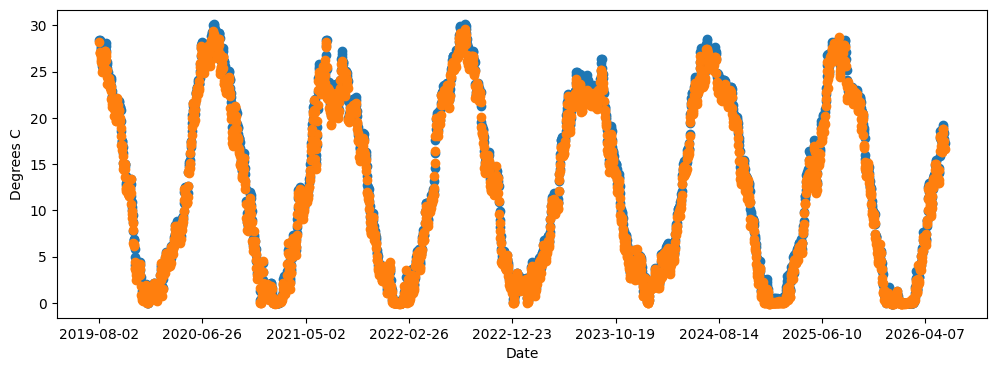

In [8]:
# figsize=(width,height) of outputted plot
plt.figure(figsize=(12,4))
plt.scatter(shared_hadtemps["date"], shared_hadtemps["value (degC)"])
plt.scatter(shared_thomtemps["date"], shared_thomtemps["value (degC)"])
plt.xticks(shared_hadtemps["date"][::300])
plt.xlabel("Date")
plt.ylabel("Degrees C")
plt.show()

In [9]:
# For some reason I don't think a linear model would fit this data well at this time scale, let's take a slice

In [10]:
sliced_hadtemps = shared_hadtemps.set_index("date")
sliced_hadtemps.sort_index(inplace=True)
sliced_hadtemps = sliced_hadtemps.loc["2019-01-01":"2019-12-31"]
sliced_hadtemps.reset_index(inplace=True)
sliced_hadtemps

,date,monitoring_location_id,parameter_code,value (degC),day_of_year
0,2019-08-02,USGS-01193050,10.0,28.478125,214
1,2019-08-03,USGS-01193050,10.0,28.447917,215
2,2019-08-04,USGS-01193050,10.0,28.273958,216
3,2019-08-05,USGS-01193050,10.0,28.311458,217
4,2019-08-06,USGS-01193050,10.0,27.829167,218
...,...,...,...,...,...
146,2019-12-26,USGS-01193050,10.0,0.648958,360
147,2019-12-27,USGS-01193050,10.0,0.889583,361
148,2019-12-28,USGS-01193050,10.0,1.220833,362
149,2019-12-29,USGS-01193050,10.0,1.282292,363


In [11]:
sliced_thomtemps = shared_thomtemps.set_index("date")
sliced_thomtemps.sort_index(inplace=True)
sliced_thomtemps = sliced_thomtemps.loc["2019-01-01":"2019-12-31"]
sliced_thomtemps.reset_index(inplace=True)
sliced_thomtemps

,date,monitoring_location_id,parameter_code,value (degC),day_of_year
0,2019-08-02,USGS-01184000,10.0,28.175000,214
1,2019-08-03,USGS-01184000,10.0,27.102083,215
2,2019-08-04,USGS-01184000,10.0,27.039583,216
3,2019-08-05,USGS-01184000,10.0,27.036458,217
4,2019-08-06,USGS-01184000,10.0,26.556250,218
...,...,...,...,...,...
146,2019-12-26,USGS-01184000,10.0,0.404167,360
147,2019-12-27,USGS-01184000,10.0,0.840625,361
148,2019-12-28,USGS-01184000,10.0,1.054167,362
149,2019-12-29,USGS-01184000,10.0,1.248958,363


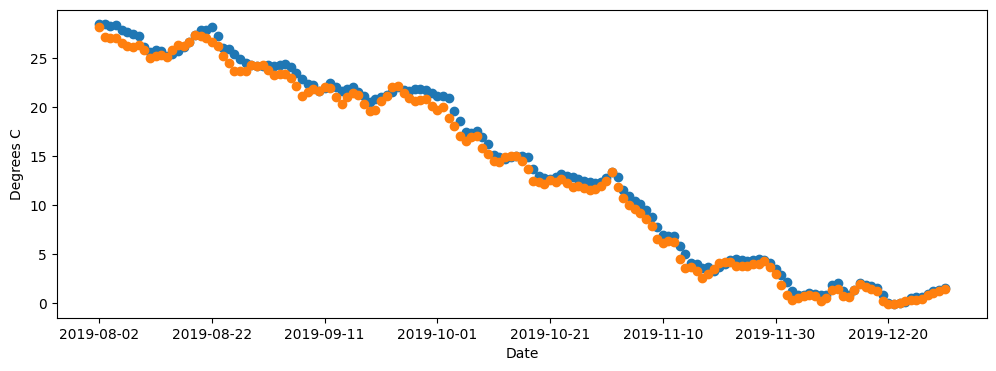

In [12]:
plt.figure(figsize=(12,4))
plt.scatter(sliced_hadtemps["date"], sliced_hadtemps["value (degC)"])
plt.scatter(sliced_thomtemps["date"], sliced_thomtemps["value (degC)"])
plt.xticks(sliced_hadtemps["date"][::20])
plt.xlabel("Date")
plt.ylabel("Degrees C")
plt.show()

In [13]:
# That's more like it, but now what?

In [14]:
slope, intercept = np.polyfit(shared_thomtemps["value (degC)"], shared_hadtemps["value (degC)"], 1)

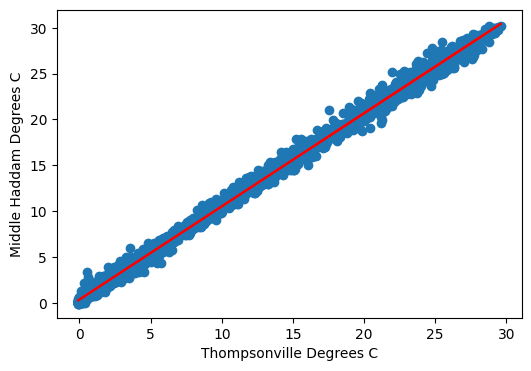

In [18]:
plt.figure(figsize=(6,4))
plt.scatter(shared_thomtemps["value (degC)"], shared_hadtemps["value (degC)"])
plt.plot(shared_thomtemps["value (degC)"], slope*np.array(shared_thomtemps["value (degC)"]) + intercept, color='red')
plt.xlabel("Thompsonville Degrees C")
plt.ylabel("Middle Haddam Degrees C")
plt.show()

In [16]:
import statsmodels.api as sm
X = shared_hadtemps["value (degC)"]
X = sm.add_constant(X)
y = shared_thomtemps["value (degC)"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           value (degC)   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 7.711e+05
Date:                Tue, 14 Jul 2026   Prob (F-statistic):               0.00
Time:                        21:06:12   Log-Likelihood:                -1888.1
No. Observations:                2457   AIC:                             3780.
Df Residuals:                    2455   BIC:                             3792.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.3112      0.018    -17.501   

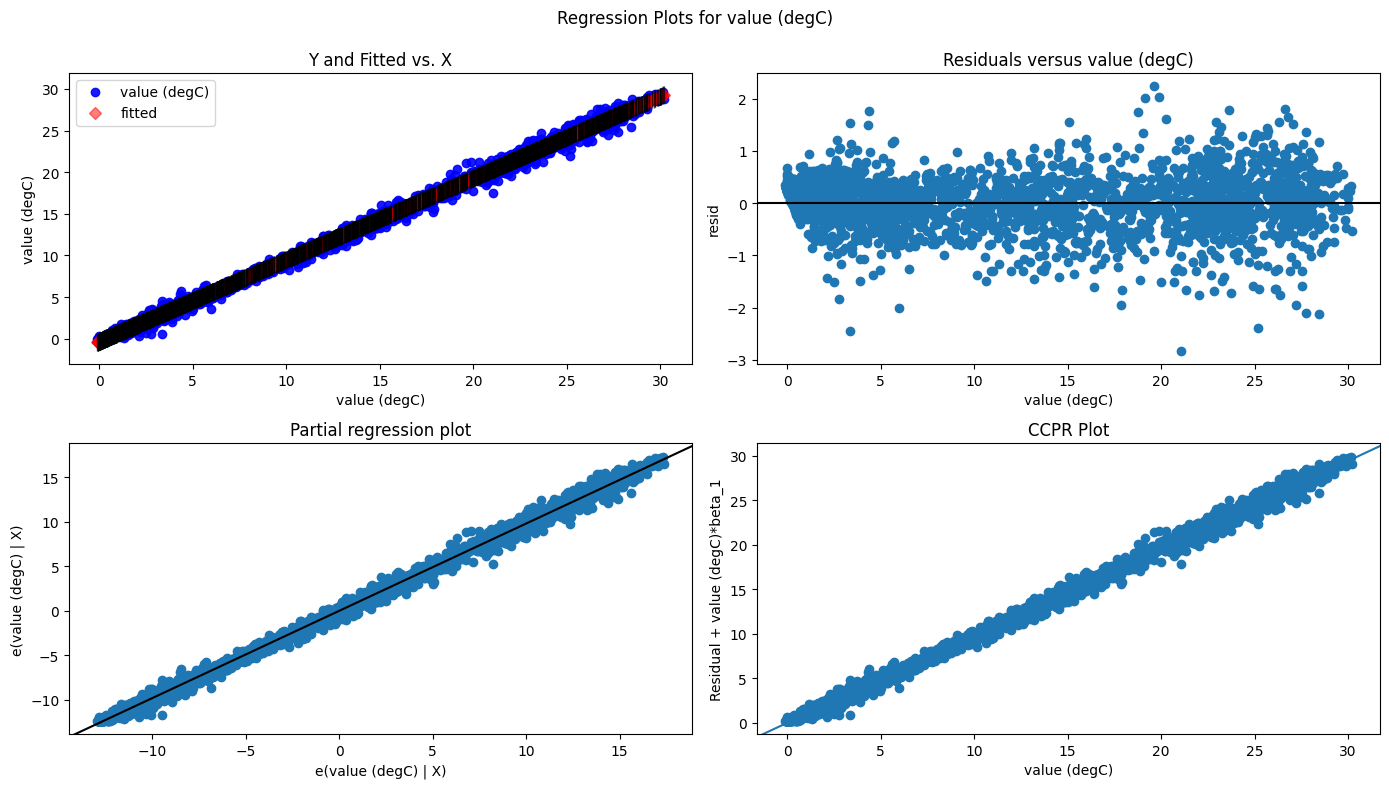

In [17]:
fig = plt.figure(figsize=(14, 8))
fig = sm.graphics.plot_regress_exog(model, "value (degC)", fig=fig)  